In [2]:
import numpy as np


In [3]:
!unzip -o archive.zip

unzip:  cannot find or open archive.zip, archive.zip.zip or archive.zip.ZIP.


In [4]:
import numpy as np

# Load train.csv
train = np.genfromtxt('/content/train.csv', delimiter=',', names=True, dtype=None,
                        encoding='utf-8')

# Load features.csv
features = np.genfromtxt('/content/features.csv', delimiter=',', names=True, dtype=None,
                           encoding='utf-8')

# Load stores.csv
stores = np.genfromtxt('/content/stores.csv', delimiter=',', names=True, dtype=None,
                         encoding='utf-8')

# Sanity checks
print("train columns:", train.dtype.names)
print("train shape:", train.shape)
print("train first row:", train[0])

print("\nfeatures columns:", features.dtype.names)
print("features shape:", features.shape)

print("\nstores columns:", stores.dtype.names)
print("stores shape:", stores.shape)

train columns: ('Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday')
train shape: (421570,)
train first row: (1, 1, '2010-02-05', 24924.5, False)

features columns: ('Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday')
features shape: (8190,)

stores columns: ('Store', 'Type', 'Size')
stores shape: (45,)


In [5]:
# Step 1: Build a lookup dictionary for stores — {store_number: (Type, Size)}
store_lookup = {row['Store']: (row['Type'], row['Size']) for row in stores}

# Step 2: Build a lookup dictionary for features — {(store, date): (Temp, Fuel, CPI, Unemployment)}
feature_lookup = {}
for row in features:
    key = (row['Store'], row['Date'])
    feature_lookup[key] = (row['Temperature'], row['Fuel_Price'], row['CPI'], row['Unemployment'])

# Step 3: Go through every row in train, and attach the matching store + feature info
merged_rows = []
for row in train:
    store_num = row['Store']
    date = row['Date']

    store_type, store_size = store_lookup.get(store_num, (None, None))
    temp, fuel, cpi, unemployment = feature_lookup.get((store_num, date), (None, None, None, None))

    merged_rows.append((store_num, row['Dept'], date, row['Weekly_Sales'], row['IsHoliday'],
                         store_type, store_size, temp, fuel, cpi, unemployment))

print("Merged rows:", len(merged_rows))
print("Sample:", merged_rows[0])

Merged rows: 421570
Sample: (np.int64(1), np.int64(1), np.str_('2010-02-05'), np.float64(24924.5), np.False_, np.str_('A'), np.int64(151315), np.float64(42.31), np.float64(2.572), np.str_('211.0963582'), np.str_('8.106'))


In [7]:
import numpy as np

# Define the structure: column names + their data types
dtype = [('Store', 'i4'), ('Dept', 'i4'), ('Date', 'U10'), ('Weekly_Sales', 'f8'),
         ('IsHoliday', '?'), ('Type', 'U1'), ('Size', 'f8'), ('Temperature', 'f8'),
         ('Fuel_Price', 'f8'), ('CPI', 'f8'), ('Unemployment', 'f8')]

# Convert the list of tuples into a structured NumPy array
merged = np.array(merged_rows, dtype=dtype)

print(merged.dtype.names)
print("=====================================")
print(merged.shape)
print("=====================================")
print(merged[0])

('Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment')
(421570,)
(1, 1, '2010-02-05', 24924.5, False, 'A', 151315.0, 42.31, 2.572, 211.0963582, 8.106)


In [8]:
for row in merged[:10]:
    print(row)

(1, 1, '2010-02-05', 24924.5, False, 'A', 151315.0, 42.31, 2.572, 211.0963582, 8.106)
(1, 1, '2010-02-12', 46039.49, True, 'A', 151315.0, 38.51, 2.548, 211.2421698, 8.106)
(1, 1, '2010-02-19', 41595.55, False, 'A', 151315.0, 39.93, 2.514, 211.2891429, 8.106)
(1, 1, '2010-02-26', 19403.54, False, 'A', 151315.0, 46.63, 2.561, 211.3196429, 8.106)
(1, 1, '2010-03-05', 21827.9, False, 'A', 151315.0, 46.5, 2.625, 211.3501429, 8.106)
(1, 1, '2010-03-12', 21043.39, False, 'A', 151315.0, 57.79, 2.667, 211.3806429, 8.106)
(1, 1, '2010-03-19', 22136.64, False, 'A', 151315.0, 54.58, 2.72, 211.215635, 8.106)
(1, 1, '2010-03-26', 26229.21, False, 'A', 151315.0, 51.45, 2.732, 211.0180424, 8.106)
(1, 1, '2010-04-02', 57258.43, False, 'A', 151315.0, 62.27, 2.719, 210.8204499, 7.808)
(1, 1, '2010-04-09', 42960.91, False, 'A', 151315.0, 65.86, 2.77, 210.6228574, 7.808)


In [9]:
import numpy as np

numeric_cols = ['Weekly_Sales', 'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

print("=== Missing value check ===")
for col in numeric_cols:
    nan_count = np.isnan(merged[col]).sum()
    pct = (nan_count / len(merged)) * 100
    print(f"{col}: {nan_count} missing ({pct:.2f}%)")

print("\nEmpty dates:", np.sum(merged['Date'] == ''))
print("Empty types:", np.sum(merged['Type'] == ''))

=== Missing value check ===
Weekly_Sales: 0 missing (0.00%)
Size: 0 missing (0.00%)
Temperature: 0 missing (0.00%)
Fuel_Price: 0 missing (0.00%)
CPI: 0 missing (0.00%)
Unemployment: 0 missing (0.00%)

Empty dates: 0
Empty types: 0


In [10]:
print("\n=== Sanity checks ===")
print("Negative Weekly_Sales count:", np.sum(merged['Weekly_Sales'] < 0))
print("Zero Weekly_Sales count:", np.sum(merged['Weekly_Sales'] == 0))
print("Min Weekly_Sales:", merged['Weekly_Sales'].min())
print("Max Weekly_Sales:", merged['Weekly_Sales'].max())


=== Sanity checks ===
Negative Weekly_Sales count: 1285
Zero Weekly_Sales count: 73
Min Weekly_Sales: -4988.94
Max Weekly_Sales: 693099.36


In [11]:
import numpy as np

# Get all unique store numbers
store_ids = np.unique(merged['Store'])
print("Number of stores:", len(store_ids))

# Calculate total revenue for each store
store_revenue = {}
for store in store_ids:
    mask = merged['Store'] == store              # True/False array: True where row belongs to this store
    total = merged['Weekly_Sales'][mask].sum()    # sum only this store's sales
    store_revenue[store] = total

# Sort from highest to lowest revenue
sorted_stores = sorted(store_revenue.items(), key=lambda x: x[1], reverse=True)

print("\nTop 5 stores by revenue:")
for store, revenue in sorted_stores[:5]:
    print(f"Store {store}: ${revenue:,.2f}")

print("\nBottom 5 stores by revenue:")
for store, revenue in sorted_stores[-5:]:
    print(f"Store {store}: ${revenue:,.2f}")

Number of stores: 45

Top 5 stores by revenue:
Store 20: $301,397,792.46
Store 4: $299,543,953.38
Store 14: $288,999,911.34
Store 13: $286,517,703.80
Store 2: $275,382,440.98

Bottom 5 stores by revenue:
Store 38: $55,159,626.42
Store 36: $53,412,214.97
Store 5: $45,475,688.90
Store 44: $43,293,087.84
Store 33: $37,160,221.96


In [12]:
import numpy as np

# Extract the month from each date string (format: 'YYYY-MM-DD')
# We slice characters 5-7 to get the "MM" part
months = np.array([date[5:7] for date in merged['Date']])

print("Sample dates:", merged['Date'][:5])
print("Extracted months:", months[:5])

# Get all unique months
unique_months = np.unique(months)
print("\nAll months found:", unique_months)

# Calculate total revenue per month (across all years combined)
monthly_revenue = {}
for month in unique_months:
    mask = months == month
    total = merged['Weekly_Sales'][mask].sum()
    monthly_revenue[month] = total

# Print sorted by month number
for month in sorted(monthly_revenue.keys()):
    print(f"Month {month}: ${monthly_revenue[month]:,.2f}")

Sample dates: ['2010-02-05' '2010-02-12' '2010-02-19' '2010-02-26' '2010-03-05']
Extracted months: ['02' '02' '02' '02' '03']

All months found: ['01' '02' '03' '04' '05' '06' '07' '08' '09' '10' '11' '12']
Month 01: $332,598,438.49
Month 02: $568,727,890.45
Month 03: $592,785,901.28
Month 04: $646,859,784.97
Month 05: $557,125,571.95
Month 06: $622,629,886.84
Month 07: $650,000,977.25
Month 08: $613,090,208.82
Month 09: $578,761,179.26
Month 10: $584,784,787.59
Month 11: $413,015,725.01
Month 12: $576,838,635.20


In [13]:
import numpy as np

# Get all unique department numbers
dept_ids = np.unique(merged['Dept'])
print("Number of departments:", len(dept_ids))

# Calculate total revenue per department (across all stores combined)
dept_revenue = {}
for dept in dept_ids:
    mask = merged['Dept'] == dept
    total = merged['Weekly_Sales'][mask].sum()
    dept_revenue[dept] = total

# Sort highest to lowest
sorted_depts = sorted(dept_revenue.items(), key=lambda x: x[1], reverse=True)

print("\nTop 5 departments by revenue:")
for dept, revenue in sorted_depts[:5]:
    print(f"Dept {dept}: ${revenue:,.2f}")

print("\nBottom 5 departments by revenue:")
for dept, revenue in sorted_depts[-5:]:
    print(f"Dept {dept}: ${revenue:,.2f}")

Number of departments: 81

Top 5 departments by revenue:
Dept 92: $483,943,341.87
Dept 95: $449,320,162.52
Dept 38: $393,118,136.92
Dept 72: $305,725,152.21
Dept 90: $291,068,463.68

Bottom 5 departments by revenue:
Dept 51: $30,572.83
Dept 78: $1,714.71
Dept 39: $177.98
Dept 43: $14.32
Dept 47: $-4,962.93


In [14]:
import numpy as np

# Step 1: Calculate overall mean and standard deviation of Weekly_Sales
mean_sales = merged['Weekly_Sales'].mean()
std_sales = merged['Weekly_Sales'].std()

print(f"Average weekly sales: ${mean_sales:,.2f}")
print(f"Standard deviation: ${std_sales:,.2f}")

# Step 2: Calculate how many standard deviations away each row is (this is called a "z-score")
z_scores = (merged['Weekly_Sales'] - mean_sales) / std_sales

# Step 3: Flag anything beyond 3 standard deviations as an anomaly
threshold = 3
anomaly_mask = np.abs(z_scores) > threshold

anomalies = merged[anomaly_mask]
print(f"\nNumber of anomalies found: {len(anomalies)}")
print(f"Percentage of total data: {len(anomalies)/len(merged)*100:.2f}%")

# Step 4: Look at a few examples
print("\nSample anomalies:")
for row in anomalies[:10]:
    print(f"Store {row['Store']}, Dept {row['Dept']}, Date {row['Date']}, Sales: ${row['Weekly_Sales']:,.2f}")

Average weekly sales: $15,981.26
Standard deviation: $22,711.16

Number of anomalies found: 8848
Percentage of total data: 2.10%

Sample anomalies:
Store 1, Dept 5, Date 2010-12-24, Sales: $85,676.09
Store 1, Dept 7, Date 2010-12-17, Sales: $96,198.12
Store 1, Dept 7, Date 2010-12-24, Sales: $166,697.72
Store 1, Dept 7, Date 2011-12-23, Sales: $119,302.15
Store 1, Dept 38, Date 2010-02-05, Sales: $115,564.35
Store 1, Dept 38, Date 2010-02-12, Sales: $94,136.35
Store 1, Dept 38, Date 2010-02-19, Sales: $98,672.59
Store 1, Dept 38, Date 2010-02-26, Sales: $92,755.59
Store 1, Dept 38, Date 2010-03-05, Sales: $108,282.86
Store 1, Dept 38, Date 2010-03-12, Sales: $98,175.35


In [15]:
high_anomalies = merged[(z_scores > 3)]
low_anomalies = merged[(z_scores < -3)]

print(f"Unusually HIGH sales weeks: {len(high_anomalies)}")
print(f"Unusually LOW sales weeks: {len(low_anomalies)}")

print("\nSample LOW anomalies (these are the ones worth worrying about):")
for row in low_anomalies[:10]:
    print(f"Store {row['Store']}, Dept {row['Dept']}, Date {row['Date']}, Sales: ${row['Weekly_Sales']:,.2f}")

Unusually HIGH sales weeks: 8848
Unusually LOW sales weeks: 0

Sample LOW anomalies (these are the ones worth worrying about):


In [16]:
import numpy as np

# First, get total sales per week (across all stores/depts) so we have one time series to forecast
unique_dates = np.unique(merged['Date'])
unique_dates_sorted = np.sort(unique_dates)

weekly_totals = []
for date in unique_dates_sorted:
    mask = merged['Date'] == date
    total = merged['Weekly_Sales'][mask].sum()
    weekly_totals.append(total)

weekly_totals = np.array(weekly_totals)
print("Number of weeks:", len(weekly_totals))
print("First 5 weekly totals:", weekly_totals[:5])

# Now calculate a moving average (e.g. average of the last 4 weeks) using convolution
window = 4
moving_avg = np.convolve(weekly_totals, np.ones(window)/window, mode='valid')

print(f"\nMoving average (last {window} weeks), most recent 5 values:")
print(moving_avg[-5:])

# Simple forecast: next week's prediction = average of the last 'window' weeks
next_week_forecast = weekly_totals[-window:].mean()
print(f"\nForecast for next week: ${next_week_forecast:,.2f}")

Number of weeks: 143
First 5 weekly totals: [49750740.5  48336677.63 48276993.78 43968571.13 46871470.3 ]

Moving average (last 4 weeks), most recent 5 values:
[45161386.1175 44970531.1175 45446150.0175 45638115.8825 46090420.105 ]

Forecast for next week: $46,090,420.10


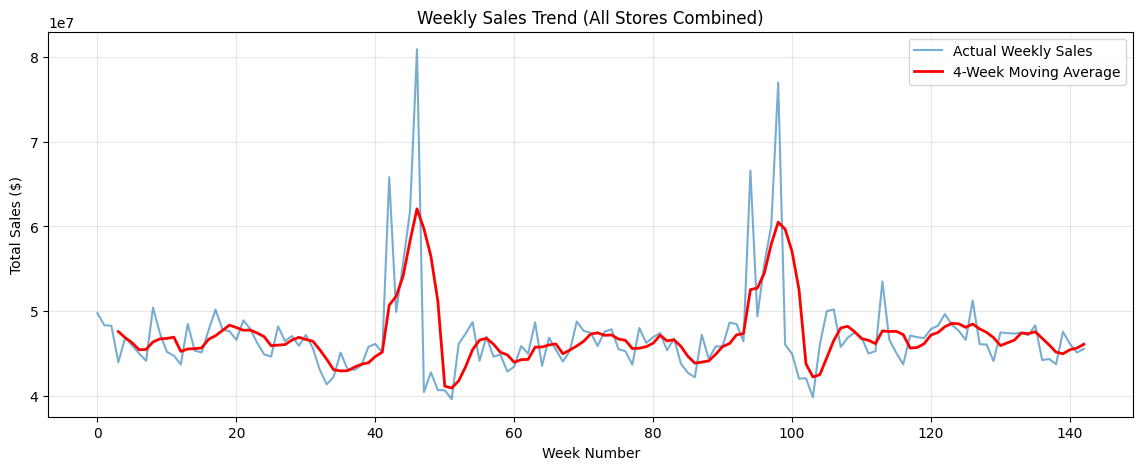

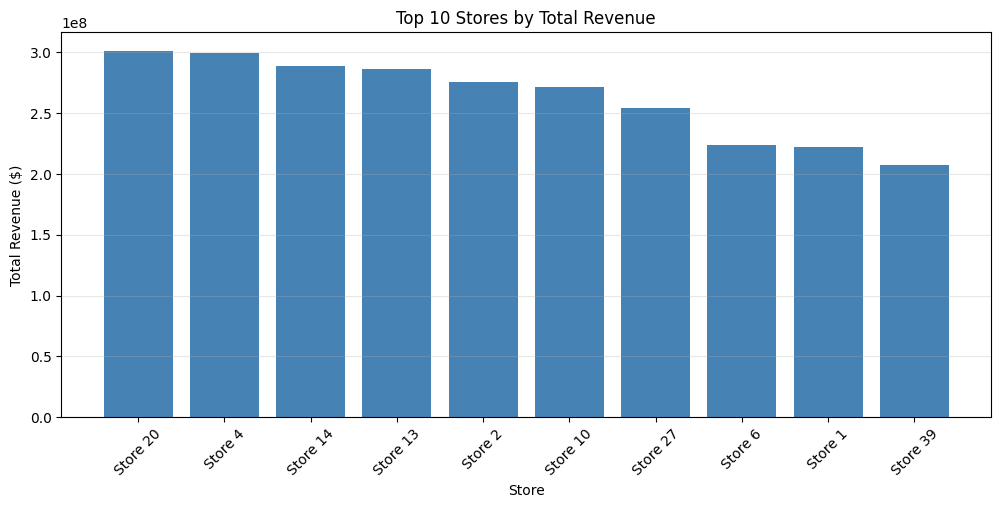

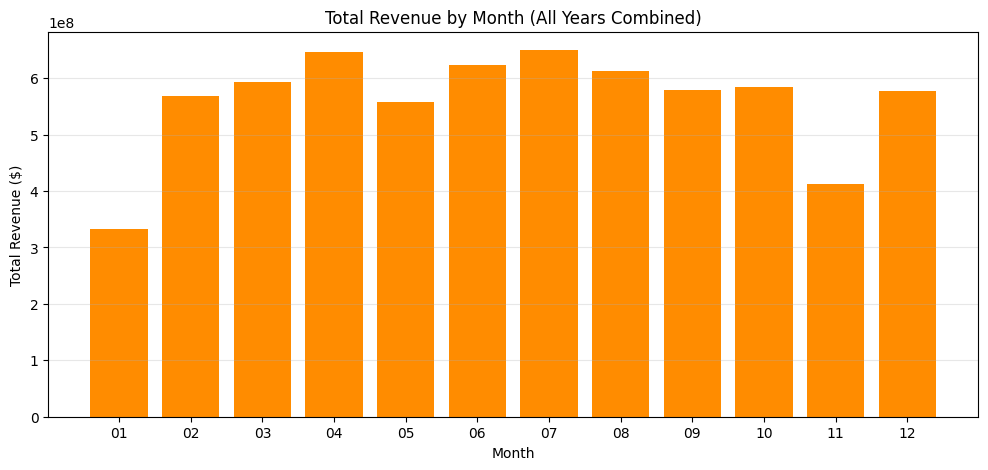

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Convert dates to a simple index for plotting (0, 1, 2, ... 142)
week_numbers = np.arange(len(weekly_totals))

# ===== Chart 1: Weekly Revenue Trend with Moving Average =====
plt.figure(figsize=(14, 5))
plt.plot(week_numbers, weekly_totals, label='Actual Weekly Sales', alpha=0.6)
plt.plot(week_numbers[window-1:], moving_avg, label=f'{window}-Week Moving Average',
          color='red', linewidth=2)
plt.title('Weekly Sales Trend (All Stores Combined)')
plt.xlabel('Week Number')
plt.ylabel('Total Sales ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ===== Chart 2: Top 10 Stores by Revenue =====
top_10_stores = sorted_stores[:10]
store_names = [f"Store {s[0]}" for s in top_10_stores]
store_values = [s[1] for s in top_10_stores]

plt.figure(figsize=(12, 5))
plt.bar(store_names, store_values, color='steelblue')
plt.title('Top 10 Stores by Total Revenue')
plt.xlabel('Store')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3, axis='y')
plt.show()

# ===== Chart 3: Monthly Revenue Pattern =====
month_labels = sorted(monthly_revenue.keys())
month_values = [monthly_revenue[m] for m in month_labels]

plt.figure(figsize=(12, 5))
plt.bar(month_labels, month_values, color='darkorange')
plt.title('Total Revenue by Month (All Years Combined)')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.grid(alpha=0.3, axis='y')
plt.show()

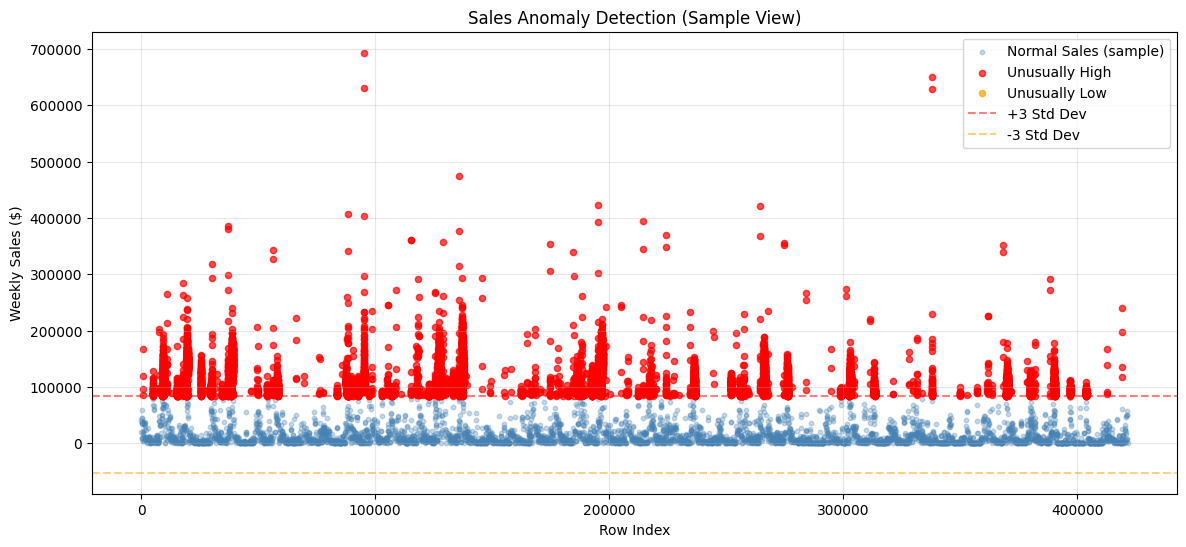

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# For performance/readability, take a random sample of "normal" points to plot as background
normal_mask = ~anomaly_mask  # everything that is NOT an anomaly
normal_indices = np.where(normal_mask)[0]
sample_indices = np.random.choice(normal_indices, 5000, replace=False)  # 5000 random normal points

plt.figure(figsize=(14, 6))

# Plot normal sales in blue (background)
plt.scatter(sample_indices, merged['Weekly_Sales'][sample_indices],
            color='steelblue', alpha=0.3, s=10, label='Normal Sales (sample)')

# Plot HIGH anomalies in red
high_indices = np.where(z_scores > 3)[0]
plt.scatter(high_indices, merged['Weekly_Sales'][high_indices],
            color='red', alpha=0.7, s=20, label='Unusually High')

# Plot LOW anomalies in orange
low_indices = np.where(z_scores < -3)[0]
plt.scatter(low_indices, merged['Weekly_Sales'][low_indices],
            color='orange', alpha=0.7, s=20, label='Unusually Low')

# Draw the threshold lines for reference
plt.axhline(mean_sales + 3*std_sales, color='red', linestyle='--', alpha=0.5, label='+3 Std Dev')
plt.axhline(mean_sales - 3*std_sales, color='orange', linestyle='--', alpha=0.5, label='-3 Std Dev')

plt.title('Sales Anomaly Detection (Sample View)')
plt.xlabel('Row Index')
plt.ylabel('Weekly Sales ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()